<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/16_random_forest_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classification

In this notebook, we implement Random Forest classification to understand ensemble learning and majority voting using multiple Decision Trees.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

In [2]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

In [3]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

model.fit(X, y)

RandomForestClassifier(max_depth=3, random_state=42)

In [4]:
predictions = model.predict(X)

predictions

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1])

In [5]:
accuracy = model.score(X, y)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [6]:
new_data = [[0.5, 1.2]]

prediction = model.predict(new_data)

print("Prediction:", prediction)

Prediction: [1]


In [7]:
importance = pd.DataFrame({
    "Feature": ["Feature_1", "Feature_2"],
    "Importance": model.feature_importances_
})

importance

,Feature,Importance
0,Feature_1,0.212984
1,Feature_2,0.787016


In [8]:
import numpy as np

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

In [9]:
Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

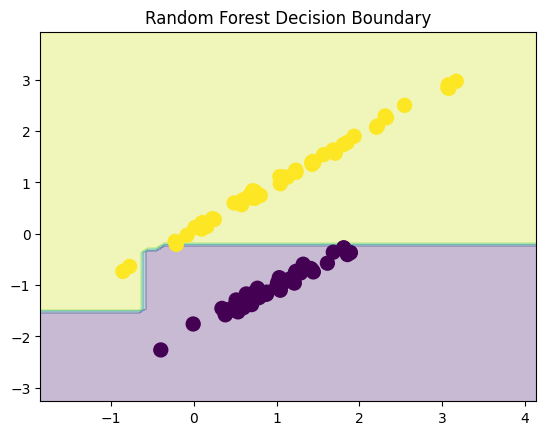

In [10]:
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    s=100
)

plt.title("Random Forest Decision Boundary")

plt.show()